In [2]:
# Import Libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

In [49]:
# Calculate sample size
def calculate_sample_size(baseline_conversion, expected_lift, alpha=0.05, power=0.8, exposure_rate=0.5):
    "Calculates total sample size for an A/B test using a Z-test for proportions."
    from scipy.stats import norm

    # Conversion rates
    p1 = baseline_conversion
    p2 = baseline_conversion + expected_lift

    # Z-scores
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)

    # Pooled standard error
    pooled_se = np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))

    # Effect size
    delta = abs(p2 - p1)

    # Adjustment factor for unequal split
    adjustment = 1 / (exposure_rate * (1 - exposure_rate))

    # Total sample size
    n_total = ((z_alpha + z_beta) ** 2 * pooled_se**2) / delta**2
    n_total_adjusted = int(np.ceil(n_total * adjustment))

    return n_total_adjusted

In [60]:
# Generate AB data
def generate_ab_data(
    baseline_conversion=0.1,
    expected_lift=0.02,
    exposure_rate=0.5,
    alpha=0.05,
    power=0.8,
    effect_size="custom"  # or "none", "small", "large"
):
    """
    Generate synthetic A/B test data using computed sample size.

    Returns:
    - DataFrame with columns ['group', 'converted']
    """

    # Compute required sample size
    n_users = calculate_sample_size(baseline_conversion, expected_lift, alpha, power,exposure_rate)

    n_B = int(n_users * exposure_rate)
    n_A = n_users - n_B

    p_A = baseline_conversion

    # Apply predefined effect sizes
    if effect_size == "custom":
        p_B = max(min(p_A + expected_lift, 1), 0)
    elif effect_size == "none":
        expected_lift = 0
        p_B = p_A
    elif effect_size == "small":
        expected_lift = 0.002
        p_B = max(min(p_A + expected_lift, 1), 0)
    elif effect_size == "large":
        expected_lift = 0.1
        p_B = max(min(p_A + expected_lift, 1), 0)

    group_A = np.random.binomial(1, p_A, n_A)
    group_B = np.random.binomial(1, p_B, n_B)

    df = pd.DataFrame({
        'group': ['A'] * n_A + ['B'] * n_B,
        'converted': np.concatenate([group_A, group_B])
    })

    return df

In [61]:
# User-defined parameters
# Custom lift
df_custom = generate_ab_data(
    baseline_conversion=0.1,
    expected_lift=0.01,
    exposure_rate=0.05,
    alpha=0.05,
    power=0.8,
    effect_size="custom"
)

# No lift
df_none = generate_ab_data(
    baseline_conversion=0.1,
    expected_lift=0.01,
    exposure_rate=0.05,
    alpha=0.05,
    power=0.8,
    effect_size="none"
)

# Large lift
df_large = generate_ab_data(
    baseline_conversion=0.1,
    expected_lift=0.01,
    exposure_rate=0.05,
    alpha=0.05,
    power=0.8,
    effect_size="large"
)

In [62]:
# Grouped summary stats
summary_custom = df_custom.groupby('group')['converted'].agg(['mean', 'count', 'sum']).reset_index()
summary_custom['scenario'] = 'custom'

summary_none = df_none.groupby('group')['converted'].agg(['mean', 'count', 'sum']).reset_index()
summary_none['scenario'] = 'none'

summary_large = df_large.groupby('group')['converted'].agg(['mean', 'count', 'sum']).reset_index()
summary_large['scenario'] = 'large'

# Combine all summaries
summary_combined = pd.concat([summary_custom, summary_none, summary_large], ignore_index=True)

# Move 'scenario' column to the front
cols = ['scenario'] + [col for col in summary_combined.columns if col != 'scenario']
summary_combined = summary_combined[cols]

# Display combined summary
summary_combined

,scenario,group,mean,count,sum
0,custom,A,0.099908,294962,29469
1,custom,B,0.108799,15524,1689
2,none,A,0.100226,294962,29563
3,none,B,0.099394,15524,1543
4,large,A,0.100230,294962,29564
5,large,B,0.196599,15524,3052


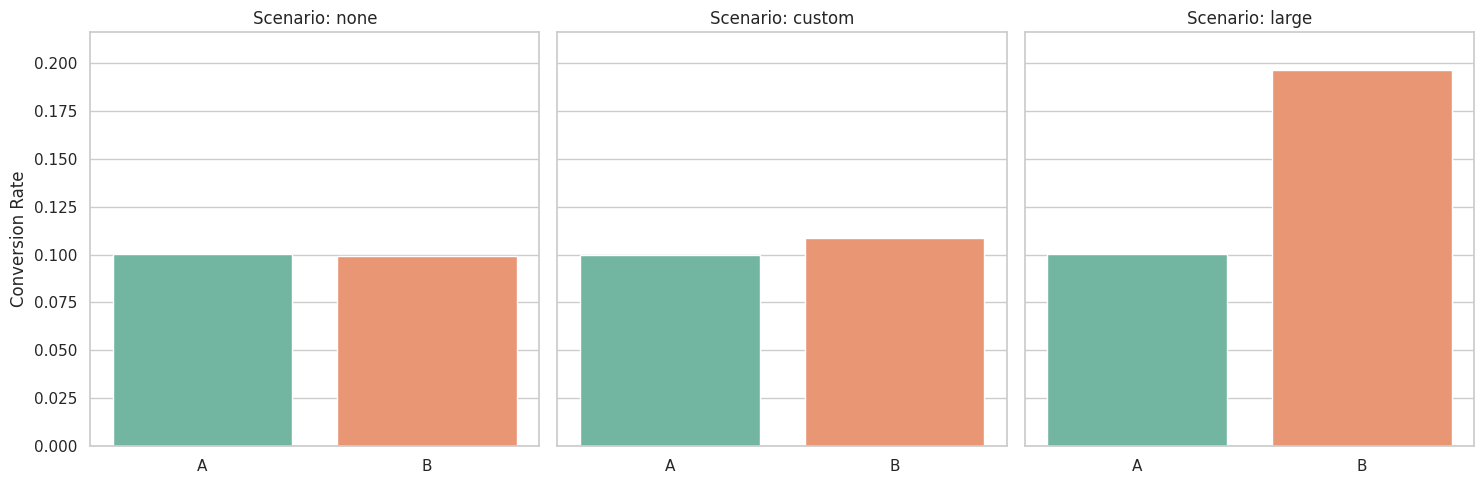

In [63]:
# Set plot style
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Define scenario list and corresponding subplot index
scenarios = ['none', 'custom', 'large']

for i, scenario in enumerate(scenarios):
    data = summary_combined[summary_combined['scenario'] == scenario]
    sns.barplot(x='group', y='mean', hue='group', data=data, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f"Scenario: {scenario}")
    axes[i].set_ylim(0, summary_combined['mean'].max() * 1.1)
    axes[i].set_ylabel('Conversion Rate' if i == 0 else '')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [64]:
# Function to interpret the pvalue
def interpret_pvalue(p_value, alpha=0.05):
    if p_value < alpha:
        return f" → Reject the null hypothesis (p = {p_value:.4f}) → evidence of an effect."
    else:
        return f" → Fail to reject the null hypothesis (p = {p_value:.4f}) → no strong evidence of an effect."

In [67]:
# Shapiro-Wilk Test for Normality
print(f"{'='*20} Shapiro-Wilk Test (Normality) {'='*20}")
print(
    "\nChecks if the sample follows a normal distribution."
    "\nNote: not ideal for binary data (0/1), but shown here for completeness."
    "\n\nHypothesis (Shapiro-Wilk Test):"
    "\n → H₀: The sample comes from a normally distributed population."
    "\n → H₁: The sample does not come from a normally distributed population."
    "\n")
print(f"{'='*70}")

def run_shapiro_test(df,name):
    stat, p = shapiro(df["converted"])

    print(f"\nExperiment: {name}, Statistic: {stat:.4f}, p-value: {p:.4f}")
    print(interpret_pvalue(p))

    return [stat, p]

# Run tests
shaphiro_none = run_shapiro_test(df_none,'None')
shaphiro_custom = run_shapiro_test(df_custom,'Custom')
shaphiro_large = run_shapiro_test(df_large,'Large')

==================== Shapiro-Wilk Test (Normality) ====================

Checks if the sample follows a normal distribution.
Note: not ideal for binary data (0/1), but shown here for completeness.

Hypothesis (Shapiro-Wilk Test):
 → H₀: The sample comes from a normally distributed population.
 → H₁: The sample does not come from a normally distributed population.


Experiment: None, Statistic: 0.3426, p-value: 0.0000
 → Reject the null hypothesis (p = 0.0000) → evidence of an effect.

Experiment: Custom, Statistic: 0.3429, p-value: 0.0000
 → Reject the null hypothesis (p = 0.0000) → evidence of an effect.

Experiment: Large, Statistic: 0.3519, p-value: 0.0000
 → Reject the null hypothesis (p = 0.0000) → evidence of an effect.


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 310486.
  res = hypotest_fun_out(*samples, **kwds)


In [68]:
# Z-Test for Proportions
print(f"{'='*20} Z-Test for Proportions {'='*20}")
print(
    "\nCompares conversion rates between two groups (A and B)."
    "\nAppropriate for large samples with binary outcomes (0/1)."
    "\n\nHypothesis (Z-Test for Proportions):"
    "\n → H₀: The conversion rates in groups A and B are equal (pA = pB)."
    "\n → H₁: The conversion rates in groups A and B are not equal (pA ≠ pB)."
    "\n")
print(f"{'='*70}")

def run_z_test(df,name):
    counts = df.groupby("group")["converted"].sum()
    n_obs = df.groupby("group")["converted"].count()
    stat, p = proportions_ztest(count=counts, nobs=n_obs)

    print(f"\nExperiment: {name}, Statistic: {stat:.4f}, p-value: {p:.4f}")
    print(interpret_pvalue(p))

    return [stat, p]

# Run tests
z_none = run_z_test(df_none,'None')
z_custom = run_z_test(df_custom,'Custom')
z_large = run_z_test(df_large,'Large')

==================== Z-Test for Proportions ====================

Compares conversion rates between two groups (A and B).
Appropriate for large samples with binary outcomes (0/1).

Hypothesis (Z-Test for Proportions):
 → H₀: The conversion rates in groups A and B are equal (pA = pB).
 → H₁: The conversion rates in groups A and B are not equal (pA ≠ pB).


Experiment: None, Statistic: 0.3365, p-value: 0.7365
 → Fail to reject the null hypothesis (p = 0.7365) → no strong evidence of an effect.

Experiment: Custom, Statistic: -3.5937, p-value: 0.0003
 → Reject the null hypothesis (p = 0.0003) → evidence of an effect.

Experiment: Large, Statistic: -38.1687, p-value: 0.0000
 → Reject the null hypothesis (p = 0.0000) → evidence of an effect.


In [71]:
# Student's t-Test (Independent Samples)
print(f"{'='*20} Student's t-Test (Independent Samples) {'='*20}")
print(
    "\nTests whether the means (i.e., conversion rates) are different."
    "\nLess ideal for binary data, but useful when sample size is large."
    "\n\nHypothesis (Z-Test for Proportions):"
    "\n → H₀: The means of the two groups are equal (μA = μB)."
    "\n → H₁: The means of the two groups are not equal (μA ≠ μB)."
    "\n")
print(f"{'='*70}")

def run_t_test(df,name):
    group_A = df[df["group"] == "A"]["converted"]
    group_B = df[df["group"] == "B"]["converted"]
    stat, p = ttest_ind(group_A, group_B)

    print(f"\nExperiment: {name}, Statistic: {stat:.4f}, p-value: {p:.4f}")
    print(interpret_pvalue(p))

    return [stat, p]

# Run tests
t_none = run_t_test(df_none,'None')
t_custom = run_t_test(df_custom,'Custom')
t_large = run_t_test(df_large,'Large')

==================== Student's t-Test (Independent Samples) ====================

Tests whether the means (i.e., conversion rates) are different.
Less ideal for binary data, but useful when sample size is large.

Hypothesis (Z-Test for Proportions):
 → H₀: The means of the two groups are equal (μA = μB).
 → H₁: The means of the two groups are not equal (μA ≠ μB).


Experiment: None, Statistic: 0.3365, p-value: 0.7365
 → Fail to reject the null hypothesis (p = 0.7365) → no strong evidence of an effect.

Experiment: Custom, Statistic: -3.5937, p-value: 0.0003
 → Reject the null hypothesis (p = 0.0003) → evidence of an effect.

Experiment: Large, Statistic: -38.2584, p-value: 0.0000
 → Reject the null hypothesis (p = 0.0000) → evidence of an effect.


In [72]:
# Mann-Whitney U Test (Non-parametric)
print(f"{'='*20} Mann-Whitney U Test (Non-parametric) {'='*20}")
print(
    "\nNon-parametric test that compares ranks of two independent samples."
    "\nUseful when normality is not assumed."
    "\nHypothesis (Mann-Whitney U Test):"
    "\n → H₀: The distributions of the two groups are equal (no shift in location)."
    "\n → H₁: The distributions of the two groups are not equal (shift in location)."
    "\n")
print(f"{'='*70}")

def run_mannwhitney_test(df,name):
    group_A = df[df["group"] == "A"]["converted"]
    group_B = df[df["group"] == "B"]["converted"]
    stat, p = mannwhitneyu(group_A, group_B, alternative='two-sided')

    print(f"\nExperiment: {name}, Statistic: {stat:.4f}, p-value: {p:.4f}")
    print(interpret_pvalue(p))

    return [stat, p]

# Run tests
mannwhitney_none = run_mannwhitney_test(df_none,'None')
mannwhitney_custom = run_mannwhitney_test(df_custom,'Custom')
mannwhitney_large = run_mannwhitney_test(df_large,'Large')

==================== Mann-Whitney U Test (Non-parametric) ====================

Non-parametric test that compares ranks of two independent samples.
Useful when normality is not assumed.
Hypothesis (Mann-Whitney U Test):
 → H₀: The distributions of the two groups are equal (no shift in location).
 → H₁: The distributions of the two groups are not equal (shift in location).


Experiment: None, Statistic: 2291399867.0000, p-value: 0.7365
 → Fail to reject the null hypothesis (p = 0.7365) → no strong evidence of an effect.

Experiment: Custom, Statistic: 2269138013.0000, p-value: 0.0003
 → Reject the null hypothesis (p = 0.0003) → evidence of an effect.

Experiment: Large, Statistic: 2068858800.0000, p-value: 0.0000
 → Reject the null hypothesis (p = 0.0000) → evidence of an effect.


In [78]:
# Bayesian A/B Test (Beta Posterior Sampling)
print(f"{'='*20} Bayesian A/B Test (Beta Posterior Sampling) {'='*20}")
print(
    "\nUses conjugate prior (Beta) with observed data (Binomial likelihood)."
    "\nReturns the posterior probability that B > A.")
print(f"{'='*70}")

def run_bayesian_ab_test_beta(df, n_samples=10000, name="Custom"):

    conversions_A = df[df["group"] == "A"]["converted"].sum()
    conversions_B = df[df["group"] == "B"]["converted"].sum()
    total_A = df[df["group"] == "A"].shape[0]
    total_B = df[df["group"] == "B"].shape[0]

    # Beta prior parameters (non-informative)
    alpha_prior = 1
    beta_prior = 1

    # Posterior samples
    samples_A = np.random.beta(alpha_prior + conversions_A, beta_prior + total_A - conversions_A, n_samples)
    samples_B = np.random.beta(alpha_prior + conversions_B, beta_prior + total_B - conversions_B, n_samples)

    prob_B_better = (samples_B > samples_A).mean()

    print(f"\nExperiment: {name}, Probability that B is better than A: {prob_B_better:.4%}")
    if prob_B_better > 0.95:
        print(" → Strong Bayesian evidence that B outperforms A.")
    elif prob_B_better < 0.05:
        print(" → Strong Bayesian evidence that A outperforms B.")
    else:
        print(" → Inconclusive evidence — further data may be needed.")


# Compute required sample size
n_users = calculate_sample_size(
    baseline_conversion=0.1,
    expected_lift=0.01,
    alpha=0.05,
    power=0.8,
    exposure_rate=0.05)

# Run tests
bayesian_none = run_bayesian_ab_test_beta(df_none,n_users,'None')
bayesian_custom = run_bayesian_ab_test_beta(df_custom,n_users,'Custom')
bayesian_large = run_bayesian_ab_test_beta(df_large,n_users,'Large')

==================== Bayesian A/B Test (Beta Posterior Sampling) ====================

Uses conjugate prior (Beta) with observed data (Binomial likelihood).
Returns the posterior probability that B > A.

Experiment: None, Probability that B is better than A: 37.3962%
 → Inconclusive evidence — further data may be needed.

Experiment: Custom, Probability that B is better than A: 99.9813%
 → Strong Bayesian evidence that B outperforms A.

Experiment: Large, Probability that B is better than A: 100.0000%
 → Strong Bayesian evidence that B outperforms A.
